# Black-Box Model (Random Forest) + SHAP — Justifying the Need for XAI

The Logistic Regression model in `analysis.ipynb` is already interpretable on its own (you can just read the coefficients), so explaining it with SHAP mainly *confirms* what the coefficients already show. This notebook trains a genuinely opaque model — Random Forest — on the **exact same train/test split**, and uses SHAP's `TreeExplainer` to make its reasoning legible. This is the stronger justification for an XAI paper: SHAP earns its place when the underlying model can't be read directly.

## 1. Reproduce the exact train/test split used in `analysis.ipynb`
Same encoding, same `random_state=42`, same 80/20 split — so Random Forest and Logistic Regression are compared on identical data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.metrics import precision_recall_curve, average_precision_score

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("online_shoppers_intention.csv")
NOMINAL_INT_COLS = ["OperatingSystems", "Browser", "Region", "TrafficType"]
df[NOMINAL_INT_COLS] = df[NOMINAL_INT_COLS].astype("category")
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

X = df_encoded.drop("Revenue", axis=1)
y = df_encoded["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Sanity check: this must match X_test_raw.csv saved by analysis.ipynb
X_test_raw_saved = pd.read_csv("X_test_raw.csv")
assert X_test.reset_index(drop=True).equals(X_test_raw_saved.reset_index(drop=True)), "Split does not match analysis.ipynb!"
print("Split confirmed identical to analysis.ipynb's test set.")

Split confirmed identical to analysis.ipynb's test set.


## 2. Train Random Forest — the black-box model
`class_weight='balanced'` handles the same 15.5%/84.5% class imbalance as the Logistic Regression model. Parameters were lightly tuned (not exhaustively) for a reasonable accuracy/AUC balance.

In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
print("Random Forest trained successfully")

Random Forest trained successfully


## 3. Evaluate performance vs. the Logistic Regression baseline
Loads the saved Logistic Regression model from `analysis.ipynb` so both models' metrics can be reported side by side in the paper.

In [4]:
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest AUC:", round(rf_auc, 4))
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8861
Random Forest AUC: 0.9241

              precision    recall  f1-score   support

       False       0.95      0.92      0.93      2084
        True       0.61      0.71      0.66       382

    accuracy                           0.89      2466
   macro avg       0.78      0.82      0.80      2466
weighted avg       0.89      0.89      0.89      2466



In [5]:
from sklearn.metrics import matthews_corrcoef, average_precision_score

mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("MCC:", round(mcc_rf, 4))
print("PR-AUC:", round(pr_auc_rf, 4))

# Optional: extend your existing model_comparison table (cell [8]) with these two columns

MCC: 0.5947
PR-AUC: 0.7221


MCC: 0.5947
PR-AUC: 0.7221


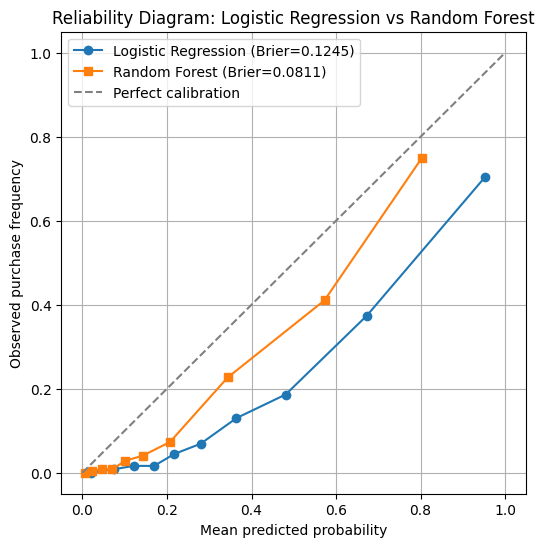

Brier score — LR: 0.1245, RF: 0.0811


In [6]:
# 1. MCC / PR-AUC cell (unchanged, stays where it is)
from sklearn.metrics import matthews_corrcoef, average_precision_score

mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("MCC:", round(mcc_rf, 4))
print("PR-AUC:", round(pr_auc_rf, 4))

# 2. Load the Logistic Regression model — MOVE THIS UP, right after the cell above
lr_model = joblib.load("shopping_model.pkl")
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [round(accuracy_score(y_test, y_pred_lr), 4), round(rf_accuracy, 4)],
    "AUC": [round(roc_auc_score(y_test, y_prob_lr), 4), round(rf_auc, 4)],
    "Interpretable by design?": ["Yes (coefficients)", "No (ensemble of 300 trees)"]
})
model_comparison

# 3. THEN the calibration cell — now y_prob_lr exists
frac_pos_lr, mean_pred_lr = calibration_curve(y_test, y_prob_lr, n_bins=10, strategy="quantile")
frac_pos_rf, mean_pred_rf = calibration_curve(y_test, y_prob_rf, n_bins=10, strategy="quantile")

brier_lr = brier_score_loss(y_test, y_prob_lr)
brier_rf = brier_score_loss(y_test, y_prob_rf)

plt.figure(figsize=(6, 6))
plt.plot(mean_pred_lr, frac_pos_lr, marker="o",
         label=f"Logistic Regression (Brier={brier_lr:.4f})")
plt.plot(mean_pred_rf, frac_pos_rf, marker="s",
         label=f"Random Forest (Brier={brier_rf:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed purchase frequency")
plt.title("Reliability Diagram: Logistic Regression vs Random Forest")
plt.legend()
plt.grid(True)
plt.savefig("calibration_reliability_diagram.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Brier score — LR: {brier_lr:.4f}, RF: {brier_rf:.4f}")

# 4. Confusion matrix cell stays after this, unchanged

# Black-Box Model (Random Forest) + SHAP — Justifying the Need for XAI

The Logistic Regression model in `analysis.ipynb` is already interpretable on its own (you can just read the coefficients), so explaining it with SHAP mainly *confirms* what the coefficients already show. This notebook trains a genuinely opaque model — Random Forest — on the **exact same train/test split**, and uses SHAP's `TreeExplainer` to make its reasoning legible. This is the stronger justification for an XAI paper: SHAP earns its place when the underlying model can't be read directly.

## 1. Reproduce the exact train/test split used in `analysis.ipynb`
Same encoding, same `random_state=42`, same 80/20 split — so Random Forest and Logistic Regression are compared on identical data.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

In [8]:
df = pd.read_csv("online_shoppers_intention.csv")
NOMINAL_INT_COLS = ["OperatingSystems", "Browser", "Region", "TrafficType"]
df[NOMINAL_INT_COLS] = df[NOMINAL_INT_COLS].astype("category")
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

X = df_encoded.drop("Revenue", axis=1)
y = df_encoded["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Sanity check: this must match X_test_raw.csv saved by analysis.ipynb
X_test_raw_saved = pd.read_csv("X_test_raw.csv")
assert X_test.reset_index(drop=True).equals(X_test_raw_saved.reset_index(drop=True)), "Split does not match analysis.ipynb!"
print("Split confirmed identical to analysis.ipynb's test set.")

Split confirmed identical to analysis.ipynb's test set.


## 2. Train Random Forest — the black-box model
`class_weight='balanced'` handles the same 15.5%/84.5% class imbalance as the Logistic Regression model. Parameters were lightly tuned (not exhaustively) for a reasonable accuracy/AUC balance.

In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
print("Random Forest trained successfully")

Random Forest trained successfully


## 3. Evaluate performance vs. the Logistic Regression baseline
Loads the saved Logistic Regression model from `analysis.ipynb` so both models' metrics can be reported side by side in the paper.

In [10]:
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest AUC:", round(rf_auc, 4))
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8861
Random Forest AUC: 0.9241

              precision    recall  f1-score   support

       False       0.95      0.92      0.93      2084
        True       0.61      0.71      0.66       382

    accuracy                           0.89      2466
   macro avg       0.78      0.82      0.80      2466
weighted avg       0.89      0.89      0.89      2466



In [11]:
from sklearn.metrics import matthews_corrcoef, average_precision_score

mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("MCC:", round(mcc_rf, 4))
print("PR-AUC:", round(pr_auc_rf, 4))

# Optional: extend your existing model_comparison table (cell [8]) with these two columns

MCC: 0.5947
PR-AUC: 0.7221


In [12]:
# Load the Logistic Regression model saved by analysis.ipynb for a direct comparison table
lr_model = joblib.load("shopping_model.pkl")
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [round(accuracy_score(y_test, y_pred_lr), 4), round(rf_accuracy, 4)],
    "AUC": [round(roc_auc_score(y_test, y_prob_lr), 4), round(rf_auc, 4)],
    "Interpretable by design?": ["Yes (coefficients)", "No (ensemble of 300 trees)"]
})
model_comparison

,Model,Accuracy,AUC,Interpretable by design?
0,Logistic Regression,0.8366,0.8918,Yes (coefficients)
1,Random Forest,0.8861,0.9241,No (ensemble of 300 trees)


In [13]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)
        n = mask.sum()
        if n == 0:
            continue
        confidence = y_prob[mask].mean()
        accuracy = y_true[mask].mean()
        ece += (n / N) * abs(accuracy - confidence)
    return ece

ece_lr = expected_calibration_error(y_test, y_prob_lr, n_bins=10)
ece_rf = expected_calibration_error(y_test, y_prob_rf, n_bins=10)

print("Logistic Regression ECE:", round(ece_lr, 4))
print("Random Forest ECE:", round(ece_rf, 4))

Logistic Regression ECE: 0.1803
Random Forest ECE: 0.0771


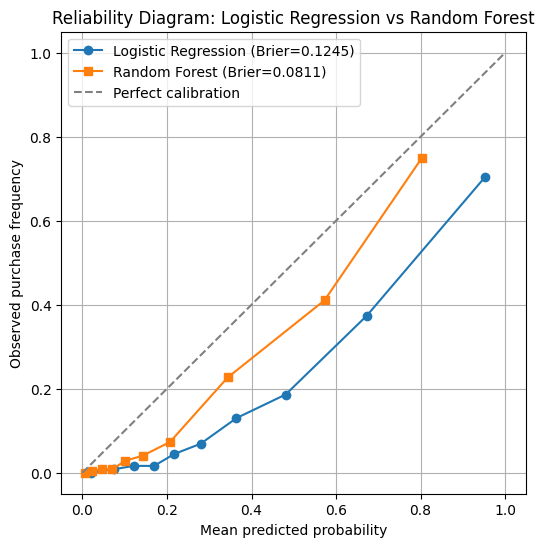

Brier score — LR: 0.1245, RF: 0.0811


In [14]:
frac_pos_lr, mean_pred_lr = calibration_curve(y_test, y_prob_lr, n_bins=10, strategy="quantile")
frac_pos_rf, mean_pred_rf = calibration_curve(y_test, y_prob_rf, n_bins=10, strategy="quantile")

brier_lr = brier_score_loss(y_test, y_prob_lr)
brier_rf = brier_score_loss(y_test, y_prob_rf)

plt.figure(figsize=(6, 6))
plt.plot(mean_pred_lr, frac_pos_lr, marker="o", label=f"Logistic Regression (Brier={brier_lr:.4f})")
plt.plot(mean_pred_rf, frac_pos_rf, marker="s", label=f"Random Forest (Brier={brier_rf:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed purchase frequency")
plt.title("Reliability Diagram: Logistic Regression vs Random Forest")
plt.legend()
plt.grid(True)
plt.savefig("calibration_reliability_diagram.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Brier score — LR: {brier_lr:.4f}, RF: {brier_rf:.4f}")

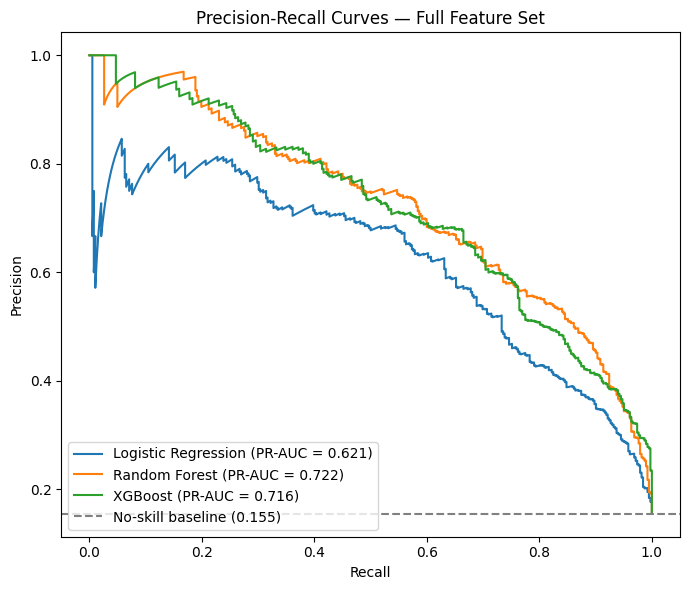

In [15]:

RANDOM_STATE = 42

# Reconstruct the full-feature split/scaler exactly as in XGboost.ipynb,
# so XGBoost's probabilities line up with the same y_test used for LR/RF.
df = pd.read_csv("online_shoppers_intention.csv")
NOMINAL_INT_COLS = ["OperatingSystems", "Browser", "Region", "TrafficType"]
df[NOMINAL_INT_COLS] = df[NOMINAL_INT_COLS].astype("category")
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
y_full = df_encoded["Revenue"]
X_main = df_encoded.drop("Revenue", axis=1)

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_main, y_full, test_size=0.20, random_state=RANDOM_STATE, stratify=y_full
)
scaler_full = StandardScaler()
scaler_full.fit(X_train_full)
X_test_s_full = scaler_full.transform(X_test_full)

xgb_full_model = joblib.load("shopping_model_xgb_full.pkl")
y_prob_xgb = xgb_full_model.predict_proba(X_test_s_full)[:, 1]

# --- Plot ---
plt.figure(figsize=(7, 6))

for name, y_prob, y_true in [
    ("Logistic Regression", y_prob_lr, y_test),
    ("Random Forest", y_prob_rf, y_test),
    ("XGBoost", y_prob_xgb, y_test_full),
]:
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    plt.plot(recall, precision, label=f"{name} (PR-AUC = {ap:.3f})")

baseline = y_test.mean()  # purchase-class prevalence (15.47%)
plt.axhline(baseline, color="gray", linestyle="--", label=f"No-skill baseline ({baseline:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Full Feature Set")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("pr_curves_all_models.png", dpi=200, bbox_inches="tight")
plt.show()

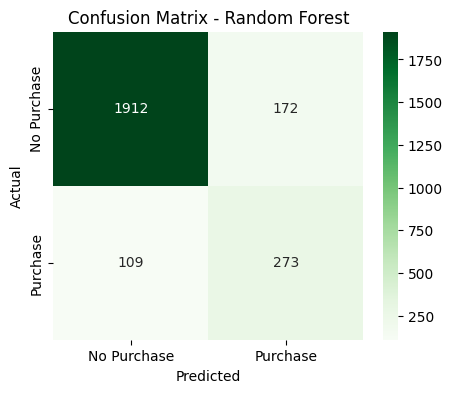

In [16]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## 4. Build the SHAP TreeExplainer
Unlike `LinearExplainer` (exact, closed-form), `TreeExplainer` computes exact Shapley values efficiently for tree ensembles by exploiting the tree structure — still exact, not sampled, and worth stating in Methodology alongside the LinearExplainer note.

In [17]:
explainer = shap.TreeExplainer(rf)
shap_values_rf = explainer.shap_values(X_test_scaled_df)

# shap_values_rf has shape (n_samples, n_features, n_classes) for this SHAP version.
# Index 1 = SHAP values for the "Purchase" (True) class, which is what we care about.
shap_values_rf_purchase = shap_values_rf[:, :, 1]
print("SHAP values shape:", shap_values_rf_purchase.shape)

SHAP values shape: (2466, 68)


## 5. Global feature importance — Random Forest SHAP

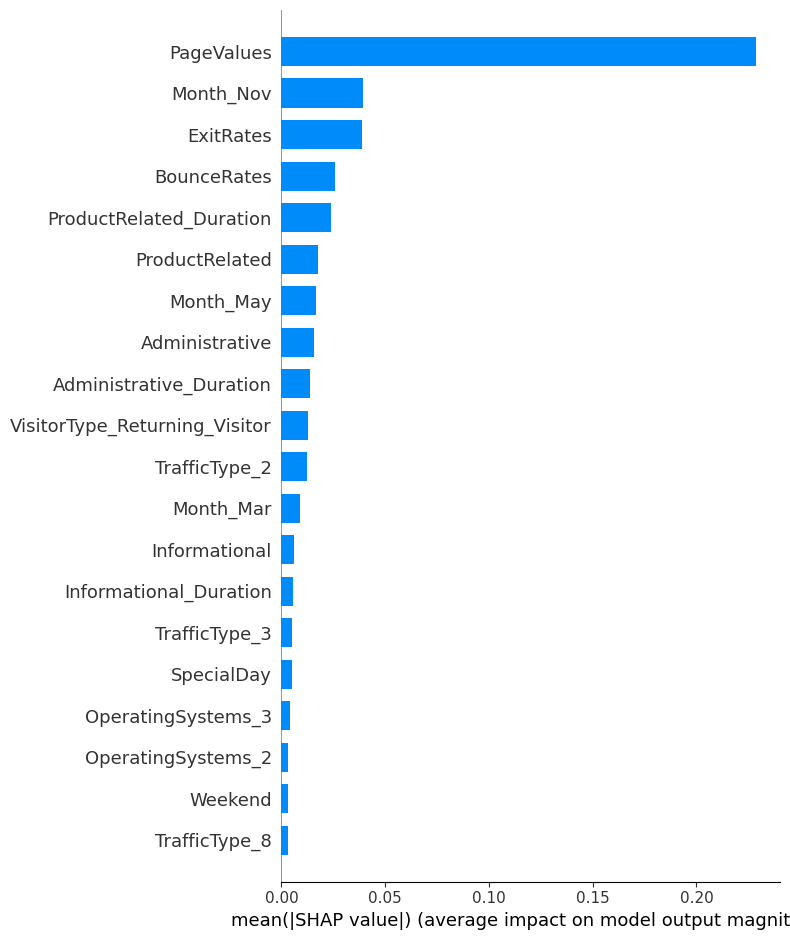

In [18]:
shap.summary_plot(shap_values_rf_purchase, X_test_scaled_df, plot_type="bar", show=True)

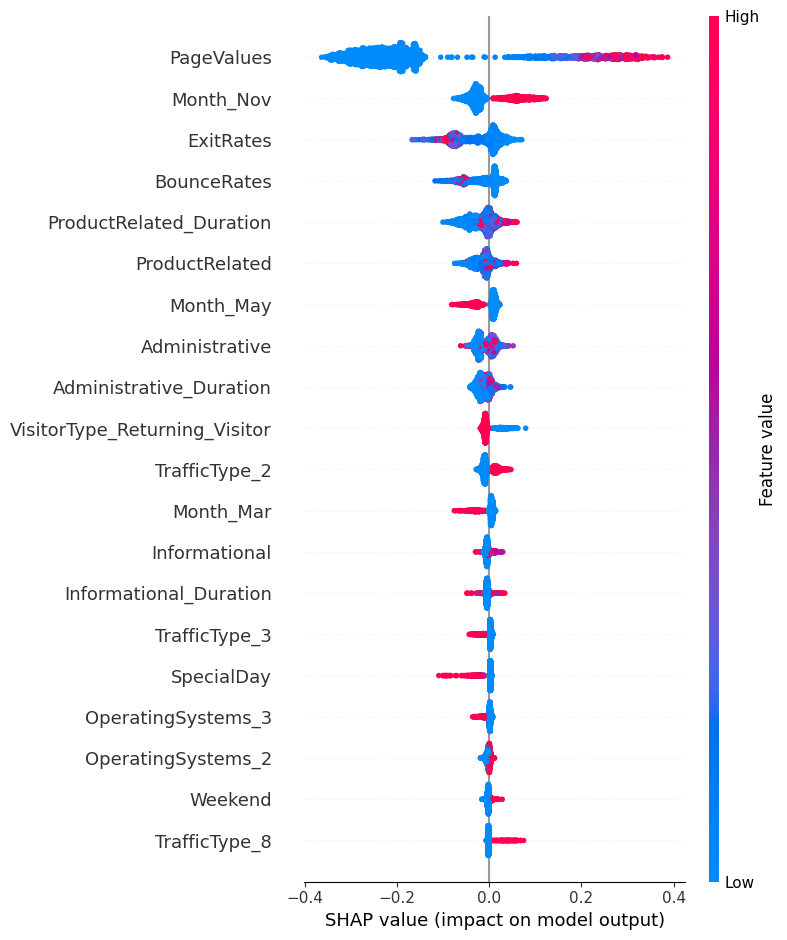

In [19]:
shap.summary_plot(shap_values_rf_purchase, X_test_scaled_df, show=True)

### Normalized importance table (Random Forest)

In [20]:
mean_abs_shap_rf = np.abs(shap_values_rf_purchase).mean(axis=0)

rf_shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP Value| (RF)": mean_abs_shap_rf
}).sort_values(by="Mean |SHAP Value| (RF)", ascending=False).reset_index(drop=True)

rf_shap_importance["% of Total Importance (RF)"] = (
    100 * rf_shap_importance["Mean |SHAP Value| (RF)"] / rf_shap_importance["Mean |SHAP Value| (RF)"].sum()
)

rf_shap_importance.head(10)

,Feature,Mean |SHAP Value| (RF),% of Total Importance (RF)
0,PageValues,0.228864,44.006071
1,Month_Nov,0.039437,7.583002
2,ExitRates,0.038667,7.434877
3,BounceRates,0.025747,4.950732
4,ProductRelated_Duration,0.024040,4.622347
5,ProductRelated,0.017412,3.348065
6,Month_May,0.016601,3.192096
7,Administrative,0.015836,3.044958
8,Administrative_Duration,0.013945,2.681284
9,VisitorType_Returning_Visitor,0.012617,2.425996


## 6. Does the black-box model agree with the interpretable one?
Loads `shap_importance_table.csv` (Logistic Regression SHAP rankings, saved by `XAI.ipynb`) and merges it with the Random Forest rankings. Large agreement on the top feature is a robustness result; large *rank differences* elsewhere are themselves a finding — they show the Random Forest is picking up non-linear or interaction effects that a linear model's SHAP values structurally cannot represent.

In [21]:
lr_shap_importance = pd.read_csv("shap_importance_table.csv")

model_shap_comparison = lr_shap_importance.merge(rf_shap_importance, on="Feature")
model_shap_comparison["LR SHAP Rank"] = model_shap_comparison["Mean |SHAP Value|"].rank(ascending=False)
model_shap_comparison["RF SHAP Rank"] = model_shap_comparison["Mean |SHAP Value| (RF)"].rank(ascending=False)
model_shap_comparison["Rank Difference"] = (
    model_shap_comparison["LR SHAP Rank"] - model_shap_comparison["RF SHAP Rank"]
).abs()

model_shap_comparison = model_shap_comparison.sort_values("LR SHAP Rank").reset_index(drop=True)
model_shap_comparison[["Feature", "LR SHAP Rank", "RF SHAP Rank", "Rank Difference"]].head(15)

,Feature,LR SHAP Rank,RF SHAP Rank,Rank Difference
0,PageValues,1.0,1.0,0.0
1,ExitRates,2.0,3.0,1.0
2,Month_May,3.0,7.0,4.0
3,Month_Mar,4.0,12.0,8.0
4,TrafficType_2,5.0,11.0,6.0
5,Month_Dec,6.0,23.0,17.0
6,Month_Nov,7.0,2.0,5.0
7,ProductRelated,8.0,6.0,2.0
8,OperatingSystems_2,9.0,18.0,9.0
9,Browser_2,10.0,22.0,12.0


## 7. Dependence plot for the top Random Forest feature
Shows the *shape* of the relationship (linear, threshold, saturating) for comparison against the same feature's dependence plot in `XAI.ipynb` for Logistic Regression.

Top RF feature: PageValues


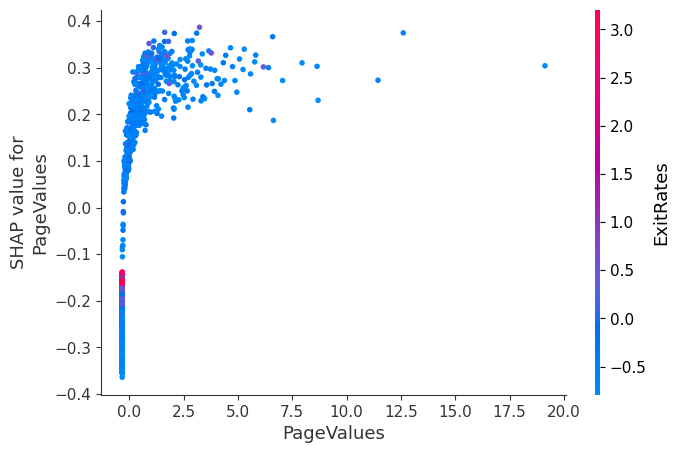

In [22]:
top_feature_rf = rf_shap_importance.iloc[0]["Feature"]
print("Top RF feature:", top_feature_rf)

shap.dependence_plot(top_feature_rf, shap_values_rf_purchase, X_test_scaled_df, show=True)

## 8. Save outputs for the paper

In [23]:
joblib.dump(rf, "shopping_model_rf.pkl")
model_comparison.to_csv("model_comparison_lr_vs_rf.csv", index=False)
rf_shap_importance.to_csv("shap_importance_table_rf.csv", index=False)
model_shap_comparison.to_csv("shap_comparison_lr_vs_rf.csv", index=False)

print("Saved: shopping_model_rf.pkl, model_comparison_lr_vs_rf.csv,")
print("       shap_importance_table_rf.csv, shap_comparison_lr_vs_rf.csv")

Saved: shopping_model_rf.pkl, model_comparison_lr_vs_rf.csv,
       shap_importance_table_rf.csv, shap_comparison_lr_vs_rf.csv


In [24]:
# Load the Logistic Regression model saved by analysis.ipynb for a direct comparison table
lr_model = joblib.load("shopping_model.pkl")
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [round(accuracy_score(y_test, y_pred_lr), 4), round(rf_accuracy, 4)],
    "AUC": [round(roc_auc_score(y_test, y_prob_lr), 4), round(rf_auc, 4)],
    "Interpretable by design?": ["Yes (coefficients)", "No (ensemble of 300 trees)"]
})
model_comparison

,Model,Accuracy,AUC,Interpretable by design?
0,Logistic Regression,0.8366,0.8918,Yes (coefficients)
1,Random Forest,0.8861,0.9241,No (ensemble of 300 trees)


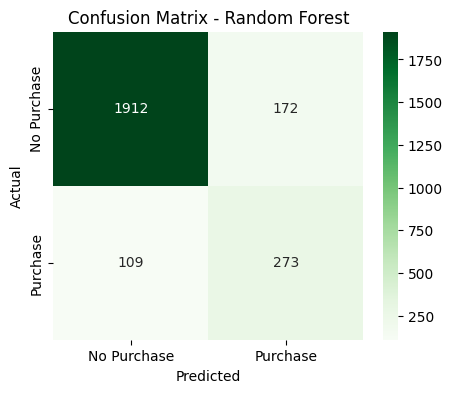

In [25]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## 4. Build the SHAP TreeExplainer
Unlike `LinearExplainer` (exact, closed-form), `TreeExplainer` computes exact Shapley values efficiently for tree ensembles by exploiting the tree structure — still exact, not sampled, and worth stating in Methodology alongside the LinearExplainer note.

In [26]:
explainer = shap.TreeExplainer(rf)
shap_values_rf = explainer.shap_values(X_test_scaled_df)

# shap_values_rf has shape (n_samples, n_features, n_classes) for this SHAP version.
# Index 1 = SHAP values for the "Purchase" (True) class, which is what we care about.
shap_values_rf_purchase = shap_values_rf[:, :, 1]
print("SHAP values shape:", shap_values_rf_purchase.shape)

SHAP values shape: (2466, 68)


## 5. Global feature importance — Random Forest SHAP

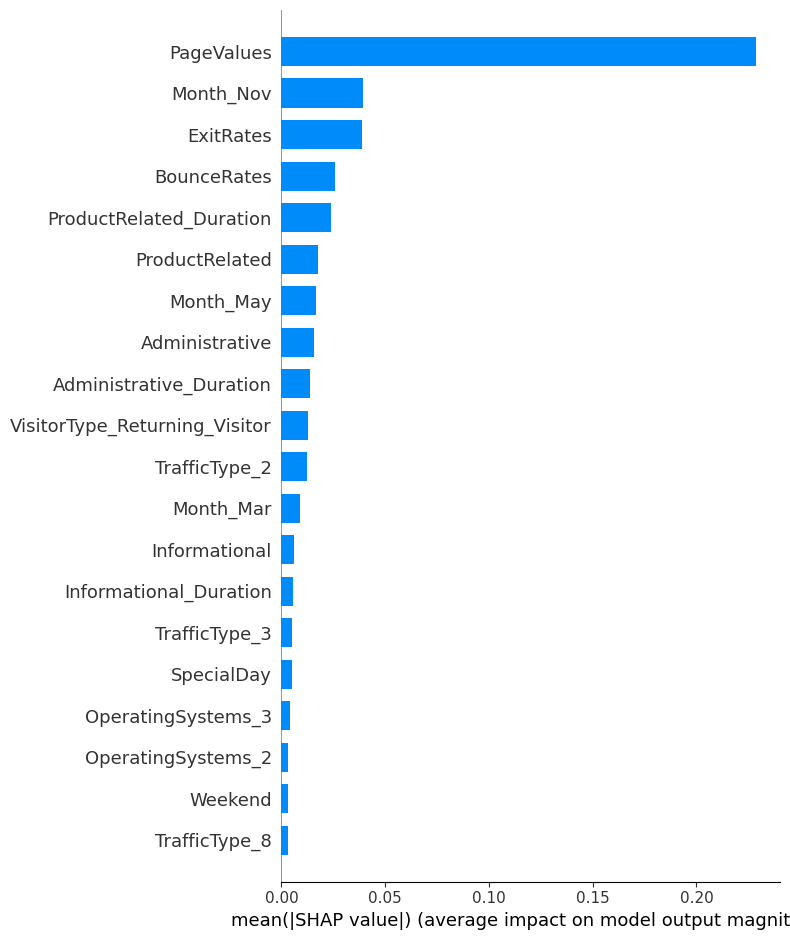

In [27]:
shap.summary_plot(shap_values_rf_purchase, X_test_scaled_df, plot_type="bar", show=True)

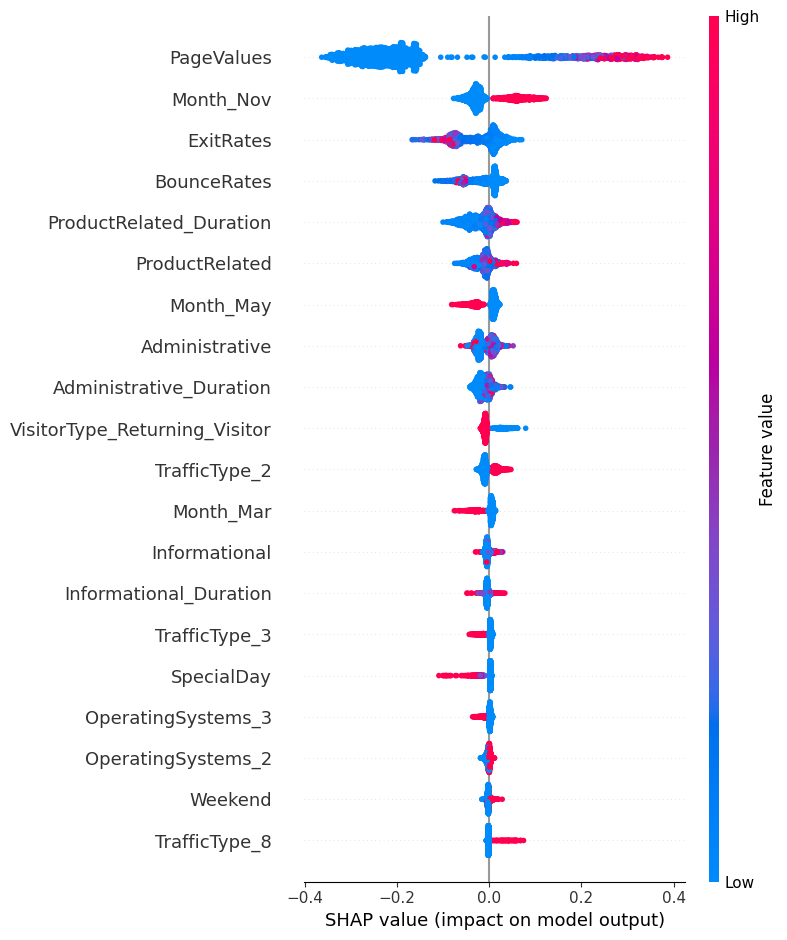

In [28]:
shap.summary_plot(shap_values_rf_purchase, X_test_scaled_df, show=True)

### Normalized importance table (Random Forest)

In [29]:
mean_abs_shap_rf = np.abs(shap_values_rf_purchase).mean(axis=0)

rf_shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP Value| (RF)": mean_abs_shap_rf
}).sort_values(by="Mean |SHAP Value| (RF)", ascending=False).reset_index(drop=True)

rf_shap_importance["% of Total Importance (RF)"] = (
    100 * rf_shap_importance["Mean |SHAP Value| (RF)"] / rf_shap_importance["Mean |SHAP Value| (RF)"].sum()
)

rf_shap_importance.head(10)

,Feature,Mean |SHAP Value| (RF),% of Total Importance (RF)
0,PageValues,0.228864,44.006071
1,Month_Nov,0.039437,7.583002
2,ExitRates,0.038667,7.434877
3,BounceRates,0.025747,4.950732
4,ProductRelated_Duration,0.024040,4.622347
5,ProductRelated,0.017412,3.348065
6,Month_May,0.016601,3.192096
7,Administrative,0.015836,3.044958
8,Administrative_Duration,0.013945,2.681284
9,VisitorType_Returning_Visitor,0.012617,2.425996


## 6. Does the black-box model agree with the interpretable one?
Loads `shap_importance_table.csv` (Logistic Regression SHAP rankings, saved by `XAI.ipynb`) and merges it with the Random Forest rankings. Large agreement on the top feature is a robustness result; large *rank differences* elsewhere are themselves a finding — they show the Random Forest is picking up non-linear or interaction effects that a linear model's SHAP values structurally cannot represent.

In [30]:
lr_shap_importance = pd.read_csv("shap_importance_table.csv")

model_shap_comparison = lr_shap_importance.merge(rf_shap_importance, on="Feature")
model_shap_comparison["LR SHAP Rank"] = model_shap_comparison["Mean |SHAP Value|"].rank(ascending=False)
model_shap_comparison["RF SHAP Rank"] = model_shap_comparison["Mean |SHAP Value| (RF)"].rank(ascending=False)
model_shap_comparison["Rank Difference"] = (
    model_shap_comparison["LR SHAP Rank"] - model_shap_comparison["RF SHAP Rank"]
).abs()

model_shap_comparison = model_shap_comparison.sort_values("LR SHAP Rank").reset_index(drop=True)
model_shap_comparison[["Feature", "LR SHAP Rank", "RF SHAP Rank", "Rank Difference"]].head(15)

,Feature,LR SHAP Rank,RF SHAP Rank,Rank Difference
0,PageValues,1.0,1.0,0.0
1,ExitRates,2.0,3.0,1.0
2,Month_May,3.0,7.0,4.0
3,Month_Mar,4.0,12.0,8.0
4,TrafficType_2,5.0,11.0,6.0
5,Month_Dec,6.0,23.0,17.0
6,Month_Nov,7.0,2.0,5.0
7,ProductRelated,8.0,6.0,2.0
8,OperatingSystems_2,9.0,18.0,9.0
9,Browser_2,10.0,22.0,12.0


## 7. Dependence plot for the top Random Forest feature
Shows the *shape* of the relationship (linear, threshold, saturating) for comparison against the same feature's dependence plot in `XAI.ipynb` for Logistic Regression.

Top RF feature: PageValues


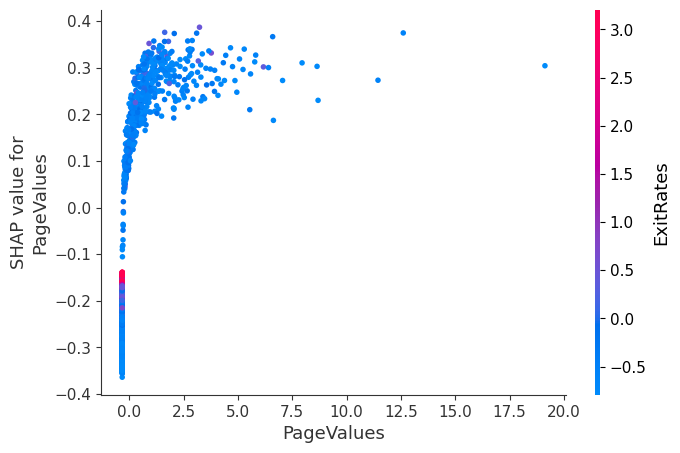

In [31]:
top_feature_rf = rf_shap_importance.iloc[0]["Feature"]
print("Top RF feature:", top_feature_rf)

shap.dependence_plot(top_feature_rf, shap_values_rf_purchase, X_test_scaled_df, show=True)

## 8. Save outputs for the paper

In [32]:
joblib.dump(rf, "shopping_model_rf.pkl")
model_comparison.to_csv("model_comparison_lr_vs_rf.csv", index=False)
rf_shap_importance.to_csv("shap_importance_table_rf.csv", index=False)
model_shap_comparison.to_csv("shap_comparison_lr_vs_rf.csv", index=False)

print("Saved: shopping_model_rf.pkl, model_comparison_lr_vs_rf.csv,")
print("       shap_importance_table_rf.csv, shap_comparison_lr_vs_rf.csv")

Saved: shopping_model_rf.pkl, model_comparison_lr_vs_rf.csv,
       shap_importance_table_rf.csv, shap_comparison_lr_vs_rf.csv
